In [11]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

data = pd.read_csv(r"C:\Users\hp\Desktop\AIDS\AIDS\spamhamdata.csv", sep='\t', encoding='latin-1', header=None)
data.columns = ['Category','Message']

data.dropna(axis=0, inplace=True)
data

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ã¼ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
le = LabelEncoder()
data['Category'] = le.fit_transform(data['Category'])

print("\nLabel classes:", le.classes_)
print("Mapping:", {label: code for label, code in zip(le.classes_, le.transform(le.classes_))})


Label classes: ['ham' 'spam']
Mapping: {'ham': np.int64(0), 'spam': np.int64(1)}


In [5]:
x = data['Message']
y = data['Category']

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

vectorizer = CountVectorizer()
xtrain_count = vectorizer.fit_transform(xtrain)
xtest_count = vectorizer.transform(xtest)

model = MultinomialNB()
ml = model.fit(xtrain_count,ytrain)

pred = ml.predict(xtest_count)

print(f'Accuracy: {accuracy_score(ytest,pred)*100:.2f}')
print('\nClassification Report:\n', classification_report(ytest,pred,target_names=le.classes_))
      

Accuracy: 99.28

Classification Report:
               precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       1.00      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [9]:
new_msg = ['Hi heg']
new_count = vectorizer.transform(new_msg)
new_pred = ml.predict(new_count)

if (new_pred==0):
    print('Ham')
else:
    print('Spam')

Ham


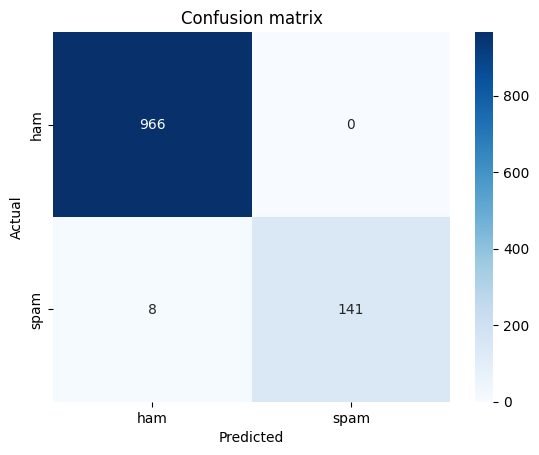

In [12]:
cm = confusion_matrix(ytest,pred)
sn.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

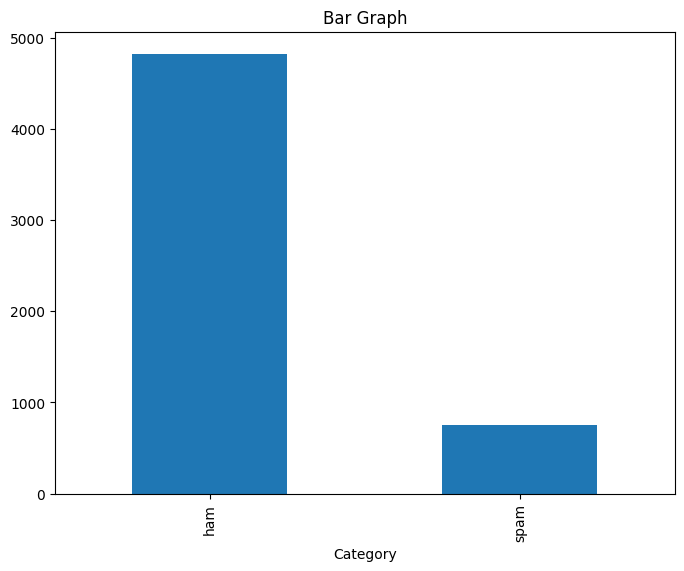

In [15]:
plt.figure(figsize=(8,6))
data['Category'].value_counts().plot(kind='bar')
plt.xticks(ticks=[0,1], labels=le.classes_)
plt.title('Bar Graph')
plt.show()